In [8]:
#networkX

import networkx as nx
import matplotlib.pyplot as plt
#방향성이 없는 그래프
G=nx.Graph()
#단일노드추가
G.add_node(1)
#여러 노드 추가
G.add_nodes_from([2,3,4])

#엣지하나추가
G.add_edge(1,2)
#엣지 여러개 추가
G.add_edges_from([(2,3),(3,4),(4,1),(3,1)])
G

In [9]:
G.add_node(1,role='Admin')#노드를 추가하는 동시에 속성 부여
G.nodes[2]['team'] ='Blue'# 이미 있는 노드에 속성 부여

#엣지에 속성 추가(가중치 weight가 가장 흔한 속성)
G.add_edge(1,2,weight=5)
G.edges[3,4]['label']='friends'

In [11]:
print('전체 노드:',G.nodes)
print('전체엣지:',G.edges)
print('1번 노드의 역할:',G.nodes[1]['role'])
print('1-2 엣지의 가중치:',G.edges[1,2]['weight'])

전체 노드: [1, 2, 3, 4]
전체엣지: [(1, 2), (1, 4), (1, 3), (2, 3), (3, 4)]
1번 노드의 역할: Admin
1-2 엣지의 가중치: 5


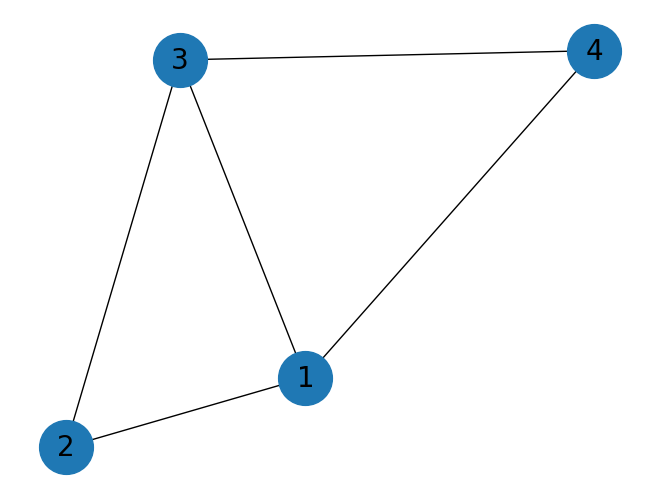

In [12]:
nx.draw(
    G,
    with_labels=True,#라벨 번호 표시
    node_size=1500,#노드 크기
    font_size=20 #노드 글자 크기
)
plt.show()

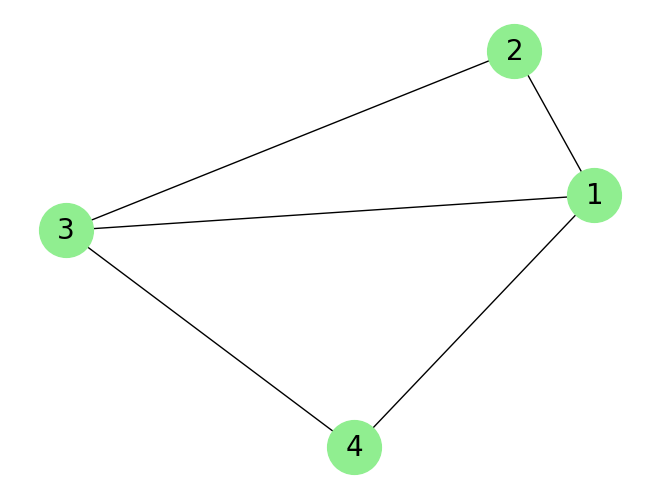

In [ ]:
#힘 기반 레이아웃 생성
pos=nx.spring_layout(G)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='lightgreen',
    node_size=1500,
    font_size=20
)
plt.show()

가중치를 5로 설정한 1,2 사이의 인력이 발생

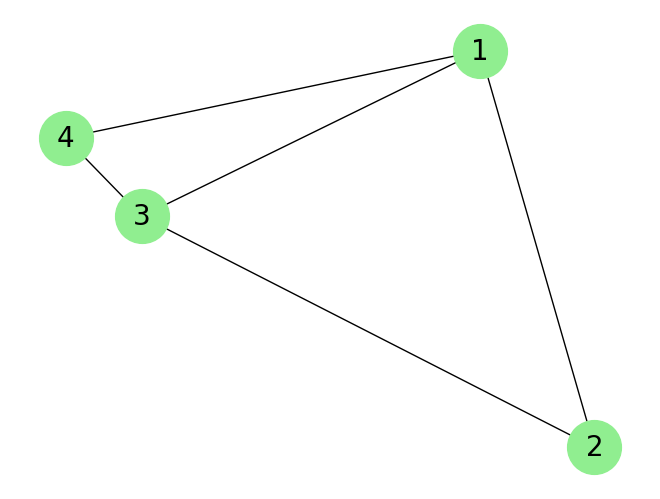

In [ ]:
G.edges[3,4]['weight']=100
pos = nx.spring_layout(G, weight='weight')#weight를 명시해야 그거 기반으로 정렬

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='lightgreen',
    node_size=1500,
    font_size=20
)
plt.show()

네트워크에서 degree다르게해서 뭐.. 차수 확인하는 부분? 시험 문제에 나올 수 있다 노드 숫자 넣으면 차수 나옴...    
예제에서는 다 2인데 ... 다르게 해서 연결중심성, 매개중심성 등 계산하기 나올듯요   

In [ ]:
#노드의 차수 분석(차수: 연결된 엣지 수)
print('전체 노드 차수',G.degree())
print('3번 노드의 차수:',G.degree(3))

전체 노드 차수 [(1, 3), (2, 2), (3, 3), (4, 2)]
3번 노드의 차수: 3


In [25]:
#연결 중심성 계산
degree_centrality=nx.degree_centrality(G)
print('연결중심성:',degree_centrality)
#매개 중심성 계산
betweenness_centrality=nx.betweenness_centrality(G)
print('매개중심성:',betweenness_centrality)
#근접중심성 계산
closeness_centrality=nx.closeness_centrality(G)
print('근접중심성:',closeness_centrality)
#고유 벡터 중심성 계산
eigenvector_centrality=nx.eigenvector_centrality(G)
print('고유 벡터 중심성:',eigenvector_centrality)

연결중심성: {1: 1.0, 2: 0.6666666666666666, 3: 1.0, 4: 0.6666666666666666}
매개중심성: {1: 0.16666666666666666, 2: 0.0, 3: 0.16666666666666666, 4: 0.0}
근접중심성: {1: 1.0, 2: 0.75, 3: 1.0, 4: 0.75}
고유 벡터 중심성: {1: 0.5573453897277424, 2: 0.43516217270028296, 3: 0.5573453897277424, 4: 0.43516217270028296}


지금 그래프는 1번과 3번이 구조적으로 완전히 대칭인 핵심 노드,
2번과 4번은 주변 노드인 형태입니다.
그래서 모든 중심성 지표가 (1,3) / (2,4) 로 정확히 갈라집니다.

- 연결중심성
    - 직접 연결된 이웃의 수
    - 1,3번 최대(1)
    - 2,4번은 1,3번보다 연결 수 적음 (0.66667)
        -   1,3이 네트워크 허브 역할
- 매개중심성
    - 다른 노드들이 서로 최단 경로로 이동할 때 중간에 얼마나 자주 등장하는지
    - 1,3번만 값이 있음 > 2,4 노드가 연결될 때 1,3을 거쳐야 하는 구조
        - 1,3이 정보 흐름의 관문
- 근접 중심성
    - 다른 모든 노드까지 얼마나 딸리 도달할 수 있는지. 평균 최단 거리의 역수
    - 1,3번=가장 가까움, 어디든 최단 거리로 접근 가능
    - 2,4번: 한 단계 더 멀다
        - 1,3이 네트워크 중심에 물리적으로 위치
- 고유벡터중심성
    - 중요한 노드와 연결되어 있으면 더 중요
    - 1,3이 가장 높음
        - 서로 중요한 노드끼리 연결
    - 2,4는 중요 노드에 의존
        - 1,3축이 네트워크의 핵심 축

In [28]:
#실습
import pandas as pd
from itertools import combinations
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
import koreanize_matplotlib
import re
from konlpy.tag import Okt

df=pd.read_csv(r'C:\Users\paint\OneDrive\Desktop\Githubproject\Dataviz\lit_practice\naver_news.csv')
df.head()

,pubDate,title,description
0,2025-12-14 21:40:00,정원오 서울시장 출마 선언 임박? “서울을 글로벌 G2 메가시티로 만들...,정원오가 생각하는 ‘서울의 비전’은?서울시장에 출마한다면 공약은?구청장 11년 동안...
1,2025-12-14 21:14:00,[스트레이트] 누구를 위한 사업인가,[이광수/부동산 전문가] &quot;기업이 그렇게 (땅을) 사는 건 흔치 않은 경우...
2,2025-12-14 19:38:00,"오세훈 &quot;정부, 10.15 대책 부작용 외면…규제 완화하라&quot;",&quot;실수요자 투기꾼 취급하는 대출 정책도 즉각 전환해야&quot; 오세훈 서...
3,2025-12-14 19:32:00,오세훈 &quot;10.15 부동산대책은 악정(惡政)&quot;,"&quot;정부, 주거 불안 해소는커녕 오히려 부추긴 꼴&quot; 오세훈 서울시장..."
4,2025-12-14 18:46:00,"[EBN 오늘(14일) 이슈 종합] 재계, 연말 인사 마무리 후 'AI 중심' 내년...",14일 업계에 따르면 주요 부동산 연구기관들은 내년 전국 집값을 보합 내지 소폭 하...


In [54]:
descriptions=df['description'].tolist()
okt=Okt()

with open(r'C:\Users\paint\OneDrive\Desktop\Githubproject\Dataviz\데이터 시각화\data\한국어불용어\stopwords-ko.txt','r',encoding='utf-8') as f:
    stopwords=f.read().splitlines()
stopwords.extend(
    ['대회','우수','주관','오세훈','서울','서울시','부동산','주요','첫째','결과','조사','아크','대비','증권','가능성','대표','시절','제자','최강','활용','최진','사례','데이터','분석']
)
all_nouns=[]
for i, text in enumerate(descriptions):
    text_cleaned=re.sub(r'[^가-힣\s]','',text)
    nouns=okt.nouns(text_cleaned)
    nouns=[word for word in set(nouns) if (len(word)>1) and word not in stopwords]
    all_nouns.append(nouns)
print(f'전처리된 단어 목록 : {all_nouns[:5]}')

전처리된 단어 목록 : [['출마', '청장', '공약', '아파트', '윤석열', '승률', '기준', '생각', '사건', '지수', '매매', '정원', '기억', '서울시장'], ['감사', '여론', '보고', '차례', '사업', '지지', '시민', '확인', '의견', '전문가', '확신', '경우', '정원', '이광수', '이건', '기업'], ['확대', '규제', '재건축', '대책', '정비', '재개발', '외면', '투기', '정책', '부작용', '사업', '취급', '완화', '정부', '대출', '즉각', '전환', '골자', '실수', '도시', '서울시장'], ['이어도', '선의', '정책', '그것', '악정', '시장', '정부', '해소', '부동산대책', '시작', '불안', '주거', '규정', '페이스북', '서울시장'], ['위원회', '수권', '충분', '집값', '업계', '건축', '기반시설', '검토', '연구기관', '번지', '하락', '내년', '내지', '보합', '도시', '공동', '여의도동', '전국']]


In [55]:
#edge리스트 생성
edge_list=[]
for nouns in all_nouns:
    if len(nouns)>2: # 단어가 2개 이상인 경우에만 처리
        edge_list.extend(combinations(sorted(nouns),2))
edge_counts=Counter(edge_list)
print(edge_counts.most_common(10))


[(('사업', '정비'), 126), (('대책', '정부'), 99), (('사업', '정부'), 76), (('대책', '시장'), 73), (('규제', '정부'), 71), (('공급', '주택'), 69), (('사업', '주택'), 66), (('구역', '사업'), 63), (('공급', '정부'), 61), (('규제', '사업'), 60)]


In [56]:
#지정된 최소 빈도 이상의 엣지만 필터링하고 빈도를 weight로 저장하는 딕셔너리 생성
min_count=20
filtered_edges={edge:weight for edge, weight in edge_counts.items() if weight >= min_count}
print(f'필터링된 엣지 개수:{len(filtered_edges)}')
#가장 가중치 높은 엣지 10개 출력
print(f'가장 가중치 높은 edge 10개: \n{sorted(filtered_edges.items(),key= lambda x:x[1],reverse=True)[:10]}')


필터링된 엣지 개수:384
가장 가중치 높은 edge 10개: 
[(('사업', '정비'), 126), (('대책', '정부'), 99), (('사업', '정부'), 76), (('대책', '시장'), 73), (('규제', '정부'), 71), (('공급', '주택'), 69), (('사업', '주택'), 66), (('구역', '사업'), 63), (('공급', '정부'), 61), (('규제', '사업'), 60)]


In [57]:
#네트워크 그래프 생성
G=nx.Graph()
weighted_edges=[
    (node1,node2,weight) for (node1,node2),weight in filtered_edges.items()
]
G.add_weighted_edges_from(weighted_edges)

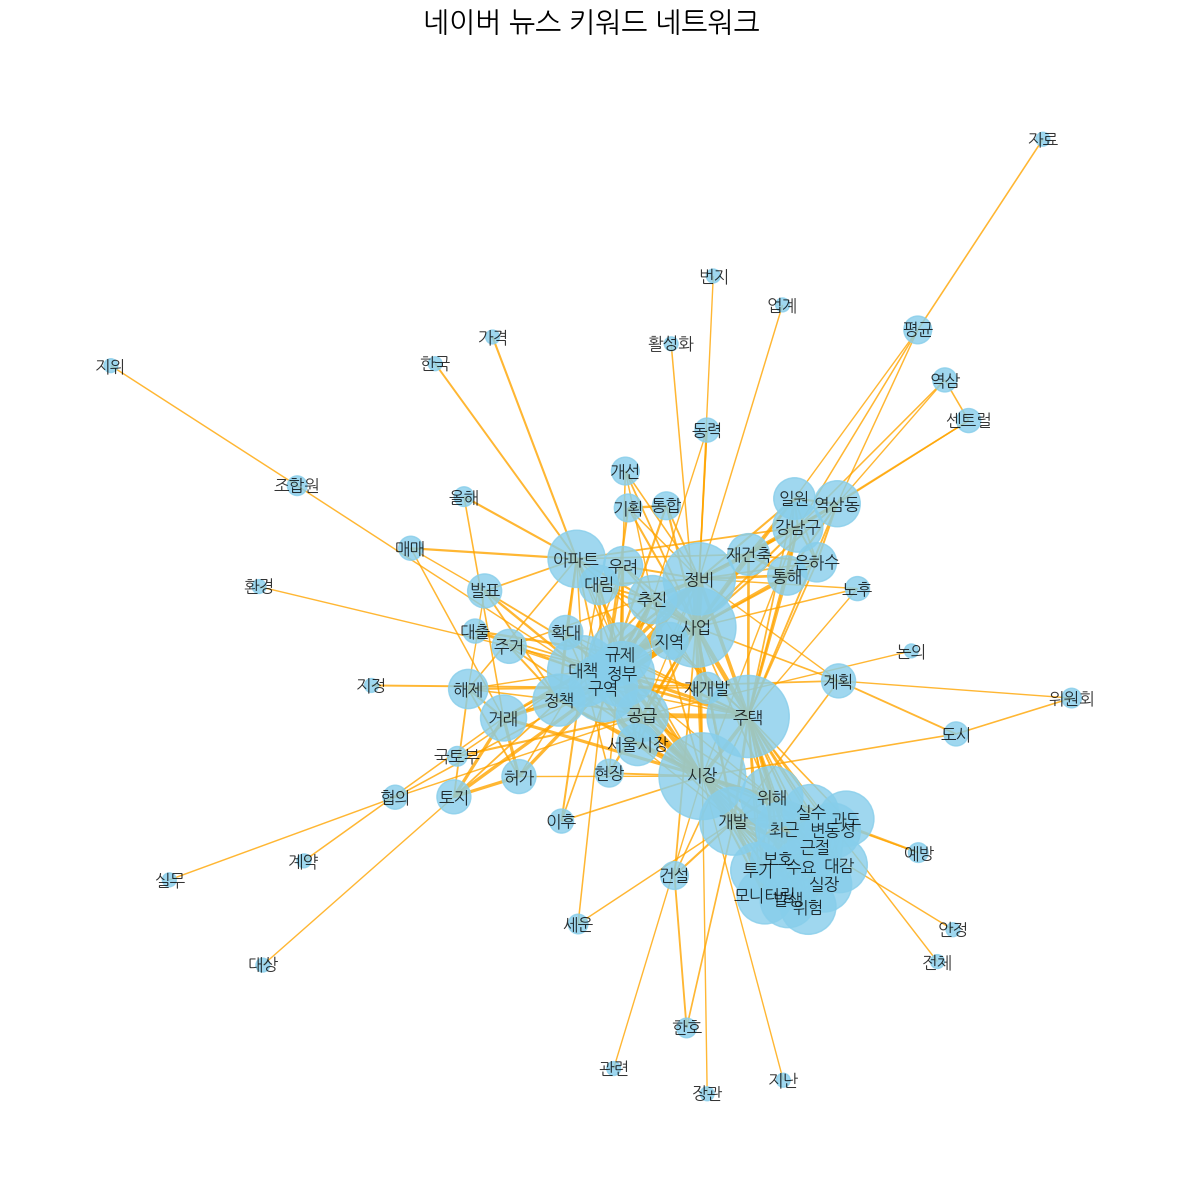

In [58]:
pos_spring=nx.spring_layout(
    G, k=0.3, iterations=50, seed=42
)
#차수기반 노드 크기 설정
node_sizes=[G.degree(node)*100 for node in G.nodes()]
#가중치 기반 엣지 두께 설정
edge_widths=[G[u][v]['weight']*0.05 for u,v in G.edges()]

plt.figure(figsize=(15,15))
nx.draw_networkx(
    G,
    pos_spring,
    with_labels=True,
    node_size=node_sizes,
    width=edge_widths,
    font_family=plt.rcParams['font.family'],
    font_size=12,
    node_color='skyblue',
    edge_color='orange',
    alpha=0.8
)
plt.title('네이버 뉴스 키워드 네트워크',size=20)
plt.axis('off')
plt.show()

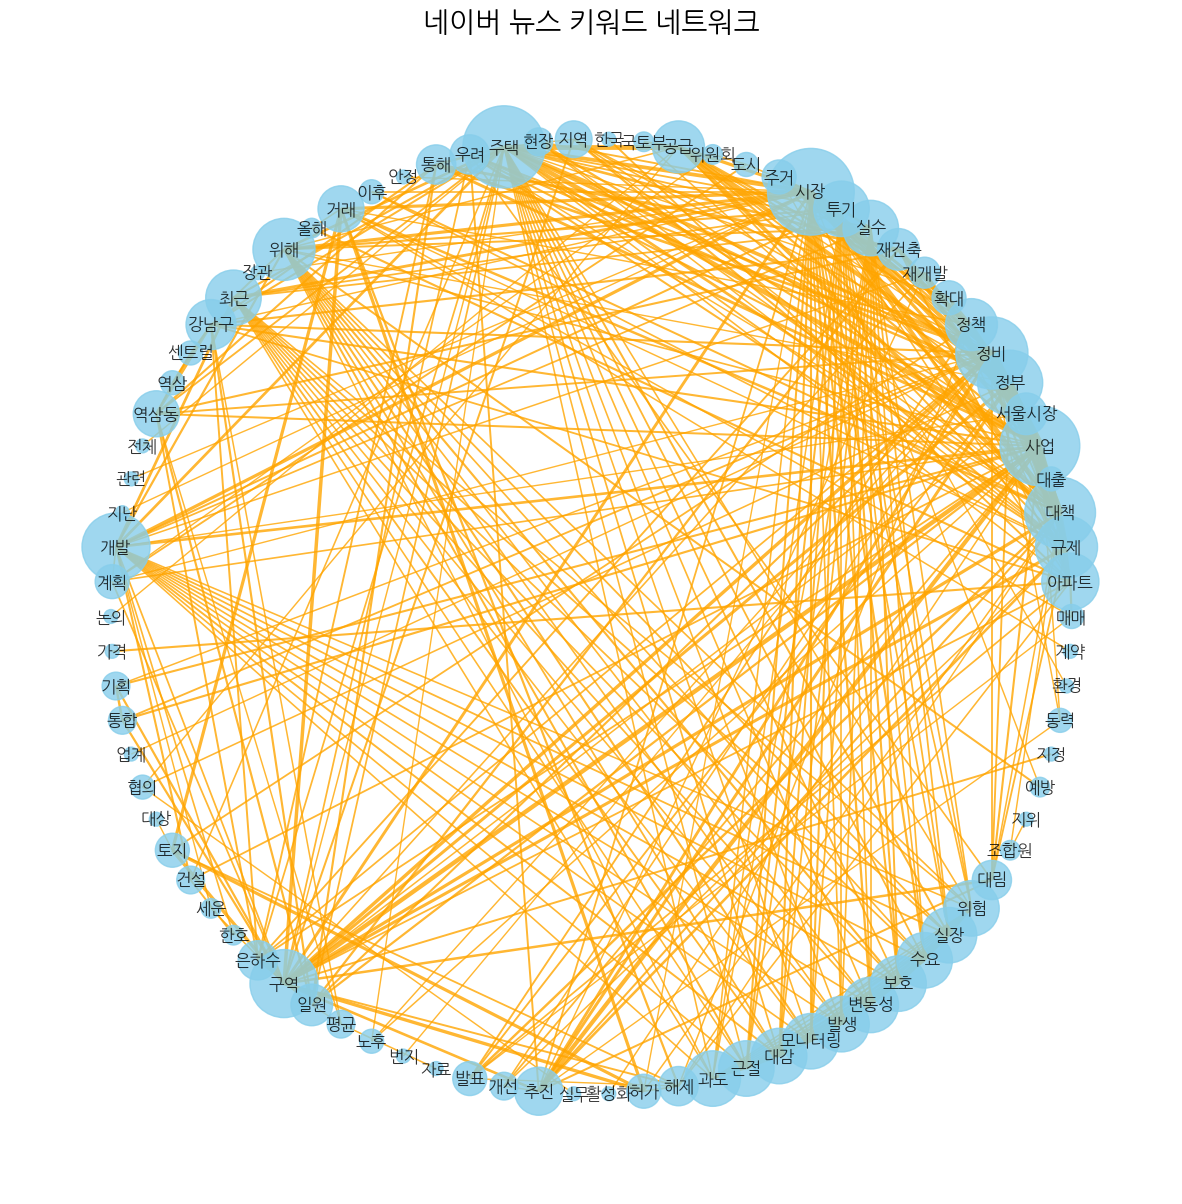

In [59]:
pos_circular=nx.circular_layout(G)
plt.figure(figsize=(15,15))
nx.draw_networkx(
    G,
    pos_circular,
    with_labels=True,
    node_size=node_sizes,
    width=edge_widths,
    font_family=plt.rcParams['font.family'],
    font_size=12,
    node_color='skyblue',
    edge_color='orange',
    alpha=0.8
)
plt.title('네이버 뉴스 키워드 네트워크',size=20)
plt.axis('off')
plt.show()